In [65]:
%matplotlib inline

In [66]:
import numpy as np

In [67]:
from matplotlib_inline import backend_inline

In [68]:
from d2l import torch as d2l

In [69]:
def f(x):
    return 3 * x ** 2 - 4 * x

In [70]:
def numerical_lim(f,x,h):  # 传入函数句柄和参数
    return (f(x+h)-f(x)) / h 

In [71]:
h = 0.1

In [72]:
for i in range(5):
    print(f'h={h:.5f},numerical limit={numerical_lim(f,1,h):.5f}')  # 输出特定精度

h=0.10000,numerical limit=2.30000
h=0.10000,numerical limit=2.30000
h=0.10000,numerical limit=2.30000
h=0.10000,numerical limit=2.30000
h=0.10000,numerical limit=2.30000


In [73]:
def use_svg_display():  #@save
    backend_inline.set_matplotlib_formats("svg")

In [74]:
def set_figsize(figsize=(3.5,2.5)): #@save
    use_svg_display()
    d2l.plt.rcParams["figure.figsize"] = figsize

In [75]:
#@save
def set_axes(axes,xlabel,ylabel,xlim,ylim,xscale,yscale,legend):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

In [76]:
def plot(X,Y=None,xlabel=None,ylabel=None,legend=None,xlim=None,ylim=None,xscale='linear',yscale='linear',fmts=('-','m--','g-','r:'),figsize=(3.5,2.5),axes=None):
    if legend is None:
        legend = []
    set_figsize(figsize)
    axes=axes if axes else d2l.plt.gca()
    
    def has_one_axis(X):
        return (hasattr(X,'ndim') and X.ndim == 1 or isinstance(X,list) and not hasattr(X[0],"__len__"))

    if has_one_axis(X):
        X = [X]

    if Y is None:
        X, Y = [[]]*len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X* len(Y)
    axes.cla()
    for x,y,fmt in zip(X,Y,fmts):
        if len(x):
            axes.plot(x,y,fmt)
        else:
            axes.plot(y,fmt)

    set_axes(axes,xlabel,ylabel,xlim,ylim,xscale,yscale,legend)

In [77]:
x = np.arange(0,3,0.1)
x = x[x!=0]  # 剔除零点

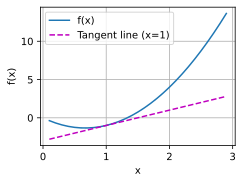

In [78]:
plot(x,[f(x),2*x-3],'x','f(x)',legend=['f(x)','Tangent line (x=1)'])

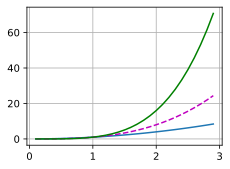

In [79]:
plot(x,[x**2,x**3,x**4])

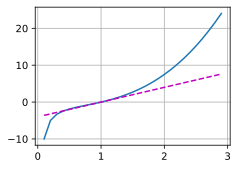

In [80]:
plot(x,[x**3-1/x,4*x-4])